In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn



In [54]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [55]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [58]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Glucose,BloodPressure,SkinThickness,Insulin,BMI is zero in original dataset which is impossible therefore replacing them with theor respective median values

In [59]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)

    df[col] = df.groupby('Outcome')[col].transform(
        lambda x: x.fillna(x.median())
    )

In [60]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<Axes: xlabel='Outcome', ylabel='Count'>

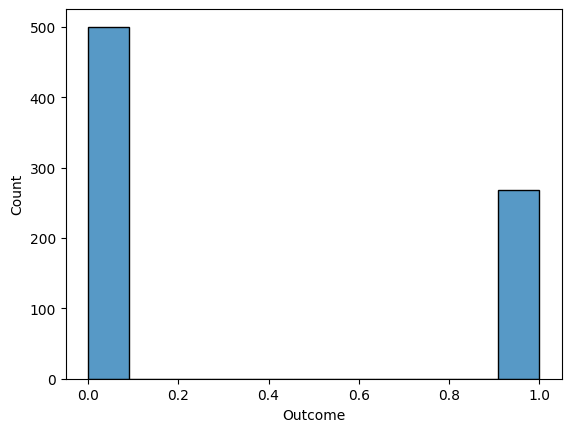

In [61]:
sns.histplot(df["Outcome"])

<Axes: xlabel='Glucose', ylabel='Count'>

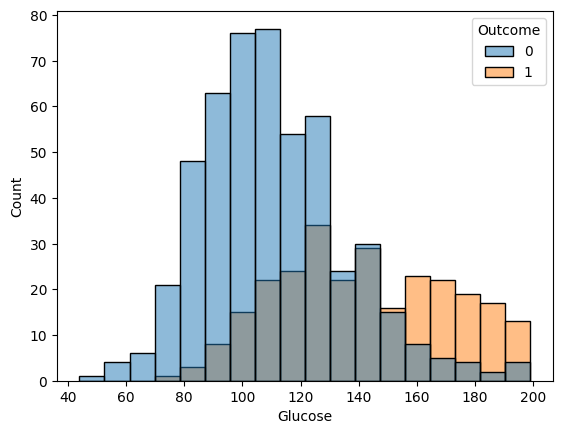

In [62]:
sns.histplot(x="Glucose", hue="Outcome", data=df, kde=False)

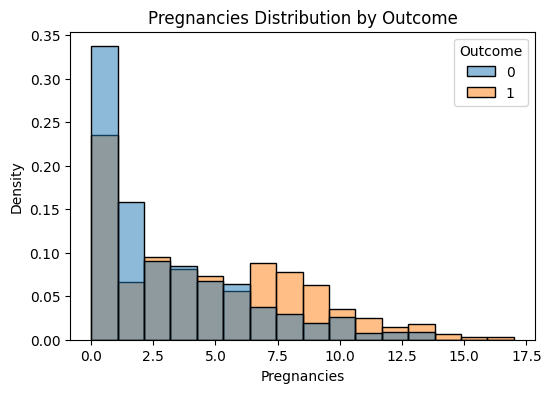

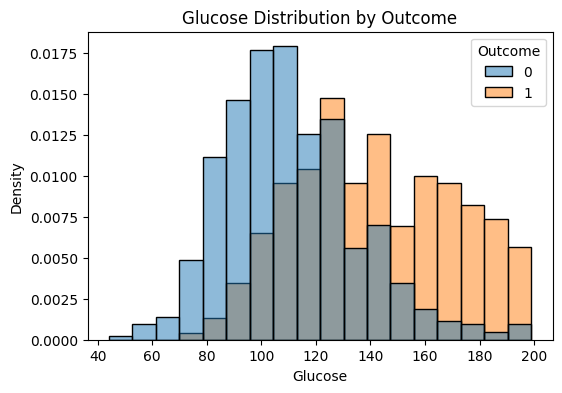

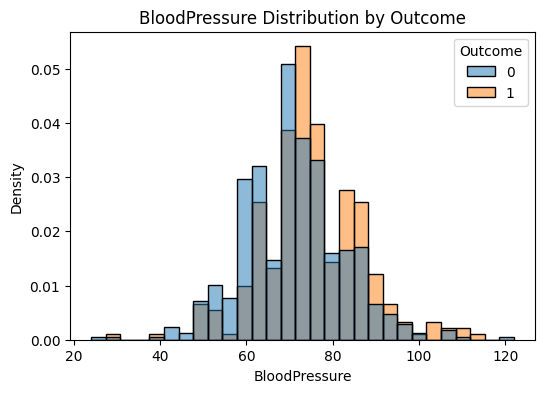

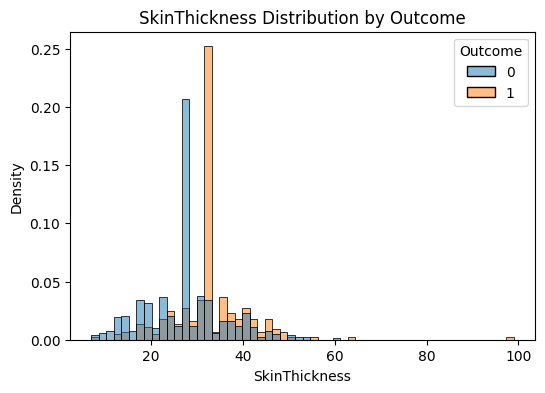

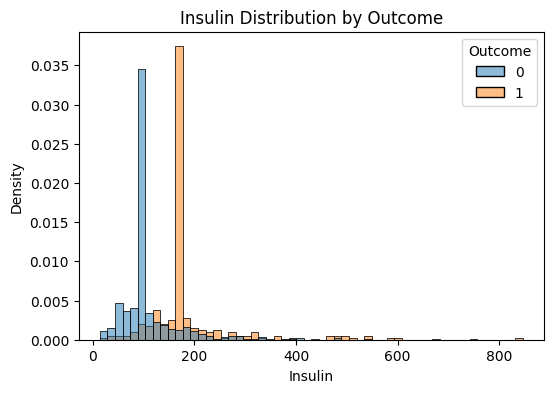

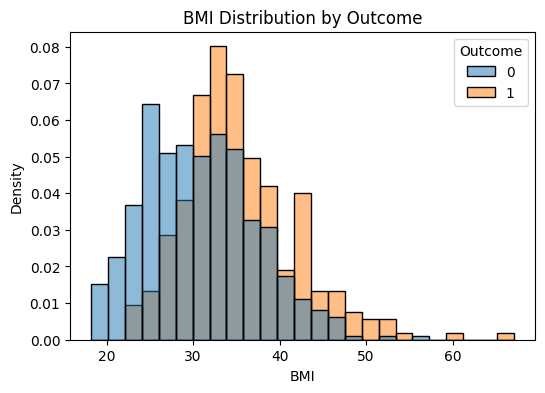

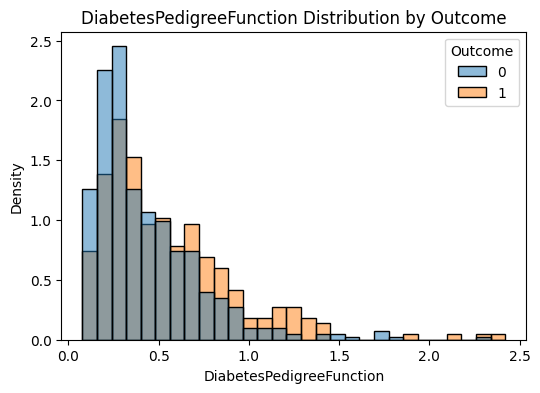

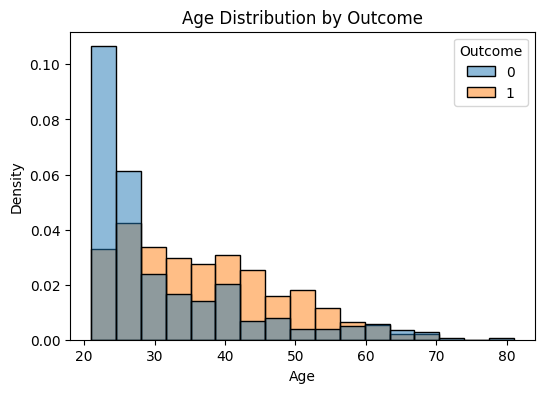

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

features = df.columns[:-1]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=feature, hue='Outcome',
                 kde=False, stat='density',
                 common_norm=False)
    plt.title(f'{feature} Distribution by Outcome')
    plt.show()

In [64]:
corr_with_diabetes = df.corr()['Outcome'].drop('Outcome').sort_values()

print("Most Positive correlation (strong diabetes signal):")
print(corr_with_diabetes.head(10))


Most Positive correlation (strong diabetes signal):
DiabetesPedigreeFunction    0.173844
BloodPressure               0.174469
Pregnancies                 0.221898
Age                         0.238356
SkinThickness               0.295138
BMI                         0.315577
Insulin                     0.377081
Glucose                     0.495990
Name: Outcome, dtype: float64


### Glusose is the strongest indicator for Diabetes,secondly Insulin and BMI


<Axes: >

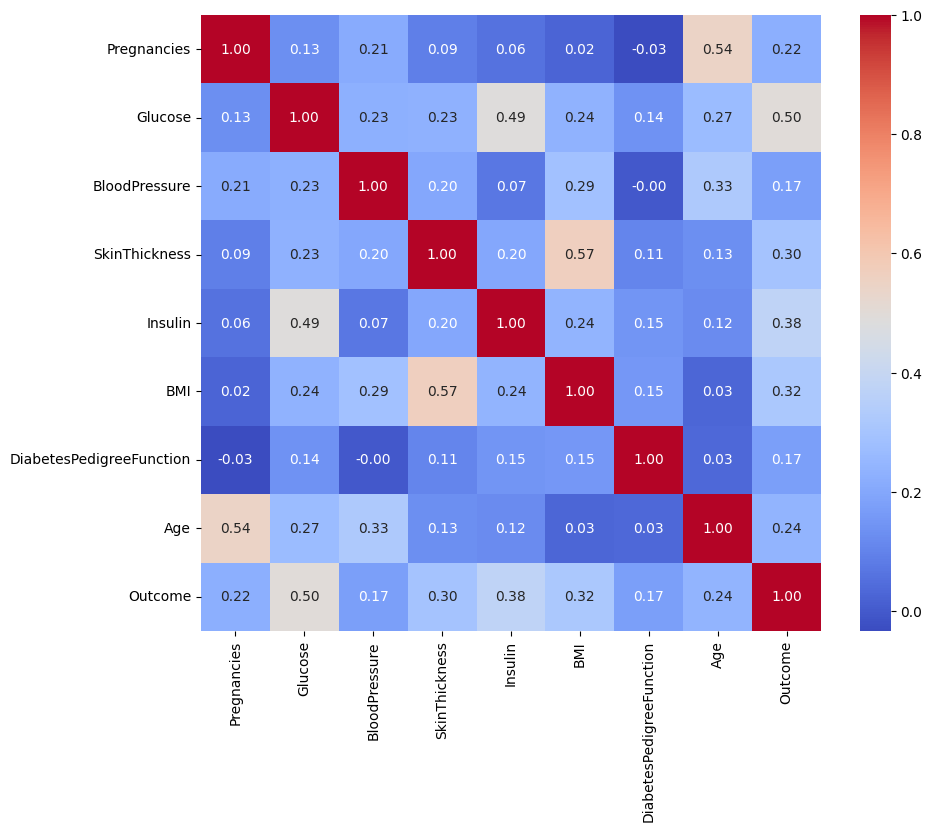

In [65]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

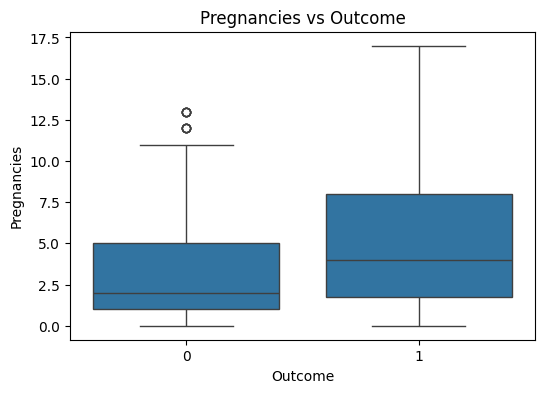

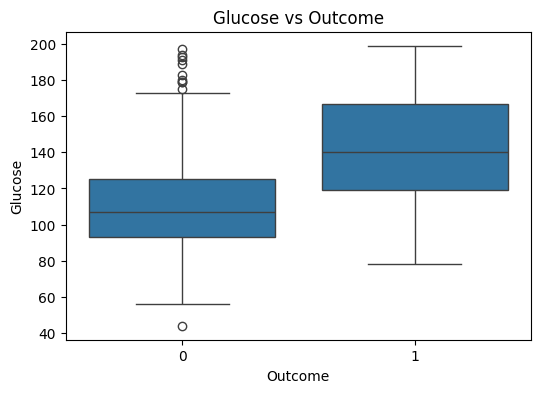

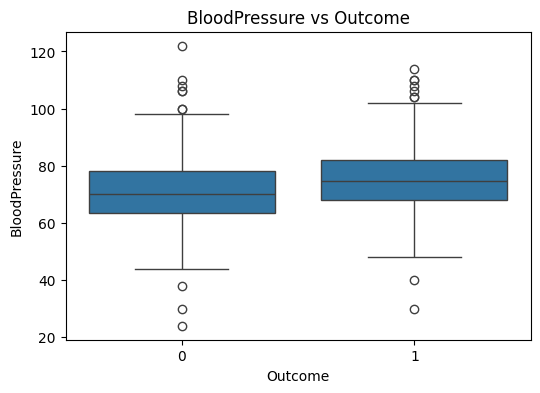

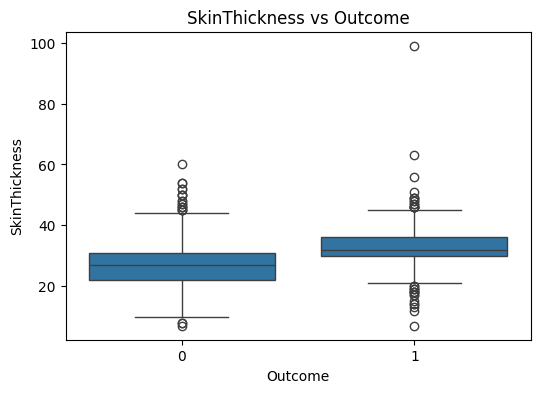

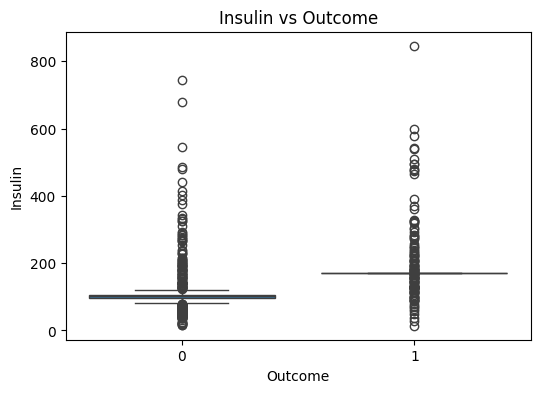

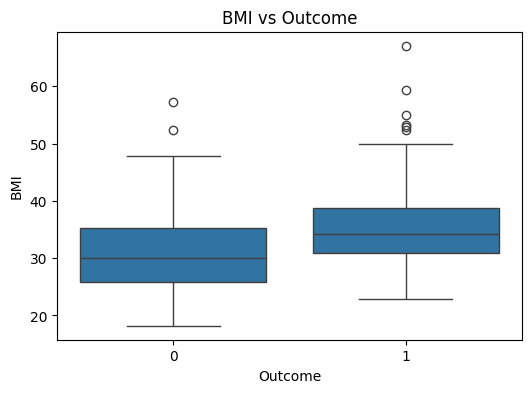

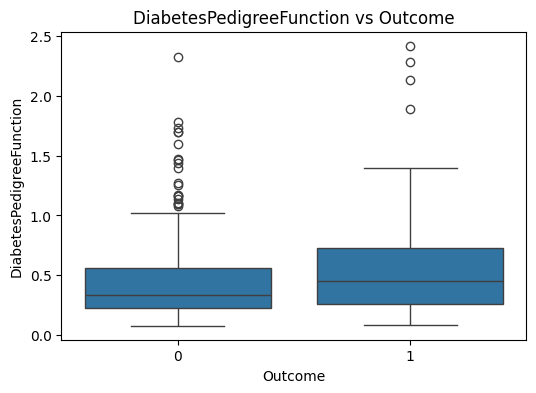

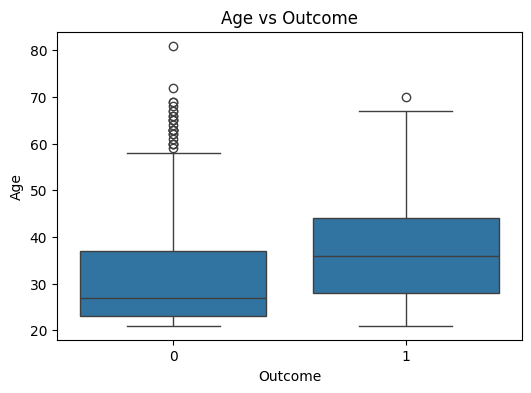

In [66]:
features = df.columns[:-1]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Outcome',
                y=feature,
                data=df)
    plt.title(f'{feature} vs Outcome')
    plt.show()

### Feature Engineering-Added two columns BMI_category and Age_group

In [67]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df['BMI_Category'] = df['BMI'].apply(bmi_category)

In [68]:
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 50:
        return "Middle-aged"
    else:
        return "Senior"
    
df['Age_Group'] = df['Age'].apply(age_group)

In [69]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Age_Group
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,Obese,Senior
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,Overweight,Middle-aged
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,Normal,Middle-aged
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,Overweight,Young
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,Obese,Middle-aged


In [70]:
df = pd.get_dummies(
    df,
    columns=['BMI_Category', 'Age_Group'],
    drop_first=True
)

In [71]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight,Age_Group_Senior,Age_Group_Young
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,True,False,False,True,False
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,False,True,False,False,False
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,False,False,False,False,False
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,False,True,False,False,True
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,True,False,False,False,False


In [72]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category_Obese,BMI_Category_Overweight,BMI_Category_Underweight,Age_Group_Senior,Age_Group_Young
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1,1,0,0,1,0
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0,0,1,0,0,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1,0,0,0,0,0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,0,1,0,0,1
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1,0,0,0,0


In [73]:
X=df.drop(columns=['Outcome'])
y=df['Outcome']

In [74]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [75]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)